Generated trace length: 2600
Unique objects: 60
Calculating reuse distances for trace length 2600...
  Processed 260/2600 (10%)
  Processed 520/2600 (20%)
  Processed 780/2600 (30%)
  Processed 1040/2600 (40%)
  Processed 1300/2600 (50%)
  Processed 1560/2600 (60%)
  Processed 1820/2600 (70%)
  Processed 2080/2600 (80%)
  Processed 2340/2600 (90%)
  Processed 2600/2600 (100%)
Finished calculating reuse distances.
Calculating miss curve from histogram...
Finished calculating miss curve.


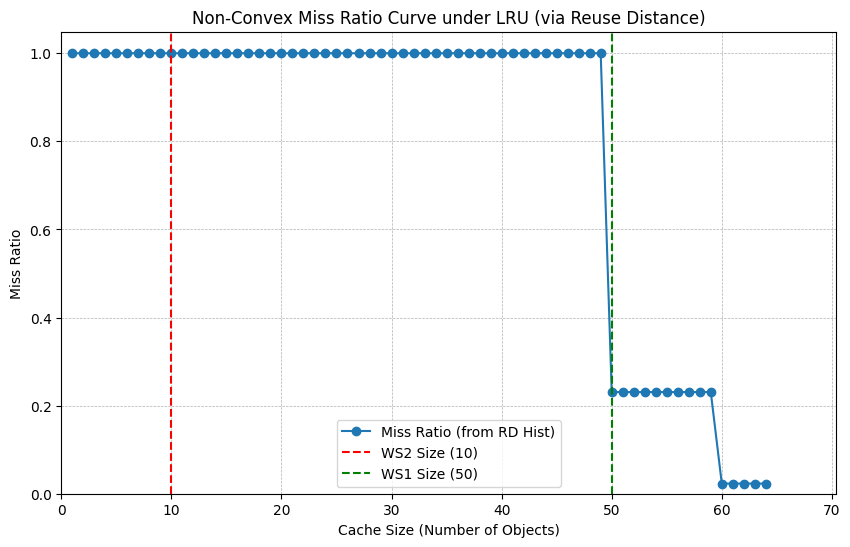

In [5]:
import collections
import matplotlib.pyplot as plt
import numpy as np # For cumulative sum

def generate_trace(s1_size, s2_size, rep1, rep2, num_cycles):
    """Generates a trace with two interleaved working sets."""
    ws1 = list(range(s1_size))
    ws2 = list(range(s1_size, s1_size + s2_size)) # Distinct objects
    
    trace = []
    for _ in range(num_cycles):
        # Access WS1 Rep1 times
        for _ in range(rep1):
            trace.extend(ws1)
        # Access WS2 Rep2 times
        for _ in range(rep2):
            trace.extend(ws2)
            
    return trace

def calculate_reuse_distances_simple(trace):
    """
    Calculates the reuse distance histogram using a list-based stack.
    Complexity: O(N*M) where N=trace length, M=max stack size (unique objects).
    Can be slow for very large traces or many unique items.
    O(N log M) or O(N) methods exist but are more complex to implement.
    """
    lru_stack = [] # Stores objects, MRU at index 0, LRU at end
    item_to_pos = {} # Maps object_id -> index in lru_stack
    reuse_hist = collections.defaultdict(int)
    print(f"Calculating reuse distances for trace length {len(trace)}...")

    for i, item in enumerate(trace):
        if (i + 1) % (len(trace) // 10 if len(trace) >= 10 else 1) == 0:
             print(f"  Processed {i+1}/{len(trace)} ({((i+1)/len(trace))*100:.0f}%)")

        if item in item_to_pos:
            # Existing item (hit)
            pos = item_to_pos[item]
            reuse_hist[pos] += 1 # Record distance (which is the position/depth)
            
            # Move to front (MRU): Remove from current pos, insert at 0
            # This is the O(M) part
            lru_stack.pop(pos)
            lru_stack.insert(0, item)
            
            # Update all positions in the map (also O(M))
            # OPTIMIZATION: only need to update map for items from index 0 to pos
            # Let's do the simple full update for clarity first.
            for current_pos, obj in enumerate(lru_stack):
                 item_to_pos[obj] = current_pos
                 
        else:
            # New item (compulsory miss)
            reuse_hist[float('inf')] += 1
            
            # Add to front (MRU)
            lru_stack.insert(0, item)
            
            # Update all positions in the map (O(M))
            for current_pos, obj in enumerate(lru_stack):
                 item_to_pos[obj] = current_pos

    print("Finished calculating reuse distances.")
    return reuse_hist

def calculate_miss_curve_from_hist(reuse_hist, trace_length):
    """Calculates miss rates for all cache sizes from a reuse distance histogram."""
    print("Calculating miss curve from histogram...")
    if not reuse_hist or trace_length == 0:
        return [], []

    # Separate compulsory misses and finite distances
    compulsory_misses = reuse_hist.get(float('inf'), 0)
    finite_distances = sorted([k for k in reuse_hist.keys() if k != float('inf')])

    if not finite_distances:
        # Only compulsory misses exist
        max_finite_dist = -1
        hist_array = np.array([])
        total_finite_reuse_count = 0
    else:
        max_finite_dist = finite_distances[-1]
        # Create histogram array for finite distances 0 to max_finite_dist
        hist_array = np.zeros(max_finite_dist + 1)
        for dist, count in reuse_hist.items():
            if dist != float('inf'):
                hist_array[dist] = count
        total_finite_reuse_count = np.sum(hist_array)

    # Calculate cumulative *hits* for finite distances
    # cumulative_hits_finite[C] = sum(hist[d] for 0 <= d < C)
    # Size C cache has C slots (0 to C-1). A hit occurs if distance d < C.
    cumulative_hits_finite = np.cumsum(hist_array)
    # Pad with 0 at the beginning for C=0 case
    cumulative_hits_finite = np.insert(cumulative_hits_finite, 0, 0) 
    
    # Determine cache sizes to plot (from 1 up to max_finite_dist + buffer)
    max_cache_size_to_plot = max_finite_dist + 5 
    cache_sizes = list(range(1, max_cache_size_to_plot + 1))
    
    miss_counts = []
    for C in cache_sizes:
        # Misses = Compulsory + Sum(h[d] for d >= C)
        
        # Sum(h[d] for d >= C) = TotalFinite - Sum(h[d] for d < C)
        if C > max_finite_dist + 1: # Cache larger than any finite distance observed
             sum_finite_ge_C = 0
        elif C <= 0: # Should not happen with range(1, ...)
             sum_finite_ge_C = total_finite_reuse_count
        else:
            # sum(h[d] for d < C) is cumulative_hits_finite[C] using our padded array
            sum_finite_lt_C = cumulative_hits_finite[C] 
            sum_finite_ge_C = total_finite_reuse_count - sum_finite_lt_C

        total_misses = compulsory_misses + sum_finite_ge_C
        miss_counts.append(total_misses)

    miss_ratios = [count / trace_length for count in miss_counts]
    print("Finished calculating miss curve.")
    return cache_sizes, miss_ratios


# --- Parameters ---
# Use smaller values for faster RD calculation with the simple method
S1_SIZE = 50       # Size of the primary working set (determines cliff location)
S2_SIZE = 10       # Size of the secondary working set
REP1 = 5           # Number of times to loop through WS1 per cycle
REP2 = 1           # Number of times to loop through WS2 per cycle
NUM_CYCLES = 10    # Number of full cycles (adjust for performance)

# --- Generate Trace ---
trace = generate_trace(S1_SIZE, S2_SIZE, REP1, REP2, NUM_CYCLES)
print(f"Generated trace length: {len(trace)}")
print(f"Unique objects: {S1_SIZE + S2_SIZE}")

# --- Calculate Reuse Distance Histogram ---
# WARNING: calculate_reuse_distances_simple can be slow O(N*M)
reuse_histogram = calculate_reuse_distances_simple(trace)

# --- Calculate Miss Curve from Histogram ---
cache_sizes, miss_ratios = calculate_miss_curve_from_hist(reuse_histogram, len(trace))

# --- Plotting ---
plt.figure(figsize=(10, 6))

if not cache_sizes:
    plt.text(0.5, 0.5, "No data to plot.", horizontalalignment='center', verticalalignment='center')
else:
    plt.plot(cache_sizes, miss_ratios, marker='o', linestyle='-', label='Miss Ratio (from RD Hist)')

    # Add vertical lines for WS sizes
    plt.axvline(x=S2_SIZE, color='r', linestyle='--', label=f'WS2 Size ({S2_SIZE})')
    plt.axvline(x=S1_SIZE, color='g', linestyle='--', label=f'WS1 Size ({S1_SIZE})')

    plt.xlabel("Cache Size (Number of Objects)")
    plt.ylabel("Miss Ratio")
    plt.title("Non-Convex Miss Ratio Curve under LRU (via Reuse Distance)")
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.ylim(bottom=0)
    plt.xlim(left=0, right=max(cache_sizes) * 1.1 if cache_sizes else 10) # Adjust xlim

plt.show()